### Kullback-Leibler divergence between two Normal distributions

#### **KL Divergence Derivation: $P = {N}(a, \sigma^2)$ and $Q = {N}(b, \sigma^2)$**

Kullback-Leibler divergence between two univariate Normal distributions with the same variance.

Given the probability density functions
- $p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-a)^2}{2\sigma^2}\right)$, $q(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-b)^2}{2\sigma^2}\right)$


Log-likelihood ratio
- $\ln\left(\frac{p}{q}\right) = \ln\left(\frac{\exp\left(-\frac{(x-a)^2}{2\sigma^2}\right)}{\exp\left(-\frac{(x-b)^2}{2\sigma^2}\right)}\right)$, $\ln\left(\frac{p}{q}\right) = -\frac{(x-a)^2}{2\sigma^2} + \frac{(x-b)^2}{2\sigma^2}$


Algebraic expansion
- $\ln\left(\frac{p}{q}\right) = \frac{1}{2\sigma^2} \left[ -(x^2 - 2ax + a^2) + (x^2 - 2bx + b^2) \right]$, $\ln\left(\frac{p}{q}\right) = \frac{1}{2\sigma^2} \left[ -x^2 + 2ax - a^2 + x^2 - 2bx + b^2 \right]$, $\ln\left(\frac{p}{q}\right) = \frac{1}{2\sigma^2} \left[ 2(a-b)x + (b^2 - a^2) \right]$


Refactoring for expectation
- To simplify the expectation under $P$, we rewrite the expression in terms of $(x-a)$: $\ln\left(\frac{p}{q}\right) = \frac{1}{2\sigma^2} \left[ 2(a-b)(x-a) + (a-b)^2 \right]$

Taking the expectation $E_P$
- $D_{KL}(P \parallel Q) = E_P\left[\ln\left(\frac{p}{q}\right)\right] = \frac{1}{2\sigma^2} \left( E_P[2(a-b)(x-a)] + E_P[(a-b)^2] \right)$

Since $E_P[x-a] = 0$ (the mean of $P$ is $a$): $D_{KL}(P \parallel Q) = \frac{(a-b)^2}{2\sigma^2}$

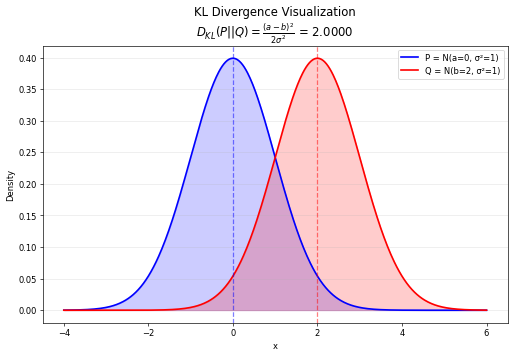

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_kl(a, b, sigma):
    # Setup the range for x
    x = np.linspace(min(a, b) - 4*sigma, max(a, b) + 4*sigma, 500)
    # Calculate PDFs
    p. q = norm.pdf(x, a, sigma), norm.pdf(x, b, sigma)
    # Calculate KL Divergence
    kl_div = ((a - b)**2) / (2 * sigma**2)
    # Plot KL Divergence / Fill the overlap/difference area for the "distance"

# parameters: a=0, b=2, sigma=1
visualize_kl(a=0, b=2, sigma=1)

### Kullback-Leibler divergence between two Bernoulli distributions.

**KL Divergence: Bernoulli Distributions $P \sim \text{Ber}(a)$ and $Q \sim \text{Ber}(b)$**

Given the probability mass functions for $x \in \{0, 1\}$
- $P(X=x) = a^x (1-a)^{1-x}$, $Q(X=x) = b^x (1-b)^{1-x}$

Definition of KL Divergence for discrete variables
- $D_{KL}(P \parallel Q) = \sum_{x \in \{0,1\}} P(X=x) \ln\left( \frac{P(X=x)}{Q(X=x)} \right)$

Expansion of the sum
- $D_{KL}(P \parallel Q) = P(X=1) \ln\left( \frac{P(X=1)}{Q(X=1)} \right) + P(X=0) \ln\left( \frac{P(X=0)}{Q(X=0)} \right)$

Substituting parameters $a$ and $b$
- $D_{KL}(P \parallel Q) = a \ln\left( \frac{a}{b} \right) + (1-a) \ln\left( \frac{1-a}{1-b} \right)$


Visualization Insight: In this context, the KL divergence measures the information gain (or "surprise") when we use distribution $Q$ to model a process that is actually governed by $P$.
- If $a = b$, the divergence is 0.
- As $b$ approaches $0$ or $1$ while $a$ stays central, the divergence grows toward infinity because $Q$ becomes "certain" about an outcome that $P$ knows is not guaranteed.

To **Visualize the KL divergence** for Bernoulli distributions, we can create a consolidated figure that shows both how the divergence behaves as a function of the modeled parameter $b$ and how it looks across the entire parameter space $(a, b)$.

The following code gives a two-panel visualization
- Left Panel: Slices of the KL divergence for fixed "true" values of $a$. This shows the convexity of the function and how the minimum always occurs at $b = a$ (where $D_{KL} = 0$).
- Right Panel: A heatmap showing the KL divergence over the unit square $(0, 1) \times (0, 1)$. This highlights how the divergence blows up as $b$ approaches the boundaries ($0$ or $1$) while $a$ is not at that boundary.

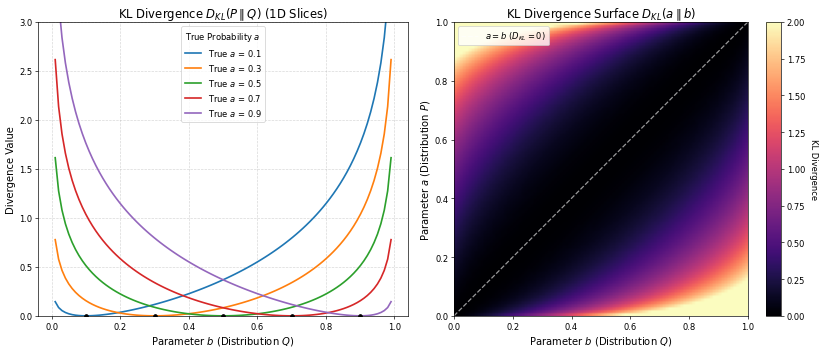

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def kl_bernoulli(a, b):
    """Computes D_KL(Ber(a) || Ber(b))"""
    eps = 1e-10  # Avoid log(0)
    a = np.clip(a, eps, 1 - eps)
    b = np.clip(b, eps, 1 - eps)
    return a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))

# Generate data for the heatmap
vals = np.linspace(0.01, 0.99, 100)
A, B = np.meshgrid(vals, vals)
Z = kl_bernoulli(A, B)

# Panel 1: 1D Slices (Fixed a, varying b)
a_targets = [0.1, 0.3, 0.5, 0.7, 0.9]
for a in a_targets:
    kl_vals = kl_bernoulli(a, vals)
    ax1.plot(vals, kl_vals, lw=2, label=f'True $a$ = {a}')
    # Mark the minimum point where a=b
    ax1.scatter([a], [0], color='black', s=20, zorder=5)

# Panel 2: Heatmap/Surface

### Kullback-Leibler divergence between two Uniform distributions.

This perfectly illustrates one of the most important properties of KL divergence: it is asymmetric and can become infinite if the support of the distributions doesn't match.

Specifically, $D_{KL}(P \parallel Q)$ is only finite if the support of $P$ is a subset of the support of $Q$. In your case, because $\theta_1 < \theta_2$, $P$ is "contained" within $Q$, making $D_{KL}(P \parallel Q)$ finite, but $D_{KL}(Q \parallel P)$ infinite.


**KL Divergence: Uniform Distributions $P = \text{Unif}(0, \theta_1)$ and $Q = \text{Unif}(0, \theta_2)$**

Given the probability density functions:$$p(x) = \frac{1}{\theta_1} \text{ for } x \in [0, \theta_1], \quad q(x) = \frac{1}{\theta_2} \text{ for } x \in [0, \theta_2]$$

Assume $0 < \theta_1 < \theta_2$.

1. Computing $D_{KL}(P \parallel Q)$
- $D_{KL}(P \parallel Q) = E_P\left[\ln\left( \frac{p(x)}{q(x)} \right)\right]$, $D_{KL}(P \parallel Q) = \int_{0}^{\theta_1} \frac{1}{\theta_1} \ln\left( \frac{1/\theta_1}{1/\theta_2} \right) dx$, $D_{KL}(P \parallel Q) = \ln\left( \frac{\theta_2}{\theta_1} \right) \int_{0}^{\theta_1} \frac{1}{\theta_1} dx = \ln\left( \frac{\theta_2}{\theta_1} \right)$

2. Computing $D_{KL}(Q \parallel P)$
- For the reverse direction, we integrate over the support of $Q$ ($[0, \theta_2]$). However, $p(x) = 0$ for $x \in (\theta_1, \theta_2]$. $D_{KL}(Q \parallel P) = \int_{0}^{\theta_1} \frac{1}{\theta_2} \ln\left( \frac{1/\theta_2}{1/\theta_1} \right) dx + \int_{\theta_1}^{\theta_2} \frac{1}{\theta_2} \ln\left( \frac{1/\theta_2}{0} \right) dx$
- The second term involves a division by zero inside the logarithm: $\lim_{p(x) \to 0^+} \ln\left( \frac{q(x)}{p(x)} \right) = \infty$. Because there is a region where $Q$ has mass but $P$ does not, the divergence is undefined (infinite): $D_{KL}(Q \parallel P) = \infty$


Conclusion $D_{KL}(P \parallel Q) \neq D_{KL}(Q \parallel P)$

Visualization

Think of $D_{KL}(P \parallel Q)$ as the "penalty" for using $Q$ to approximate $P$.
- In the first case, $Q$ covers all of $P$, so the penalty is just the difference in density.
- In the second case, $Q$ expects outcomes (between $\theta_1$ and $\theta_2$) that $P$ says are impossible. Predicting something "impossible" as "possible" results in an infinite information loss.

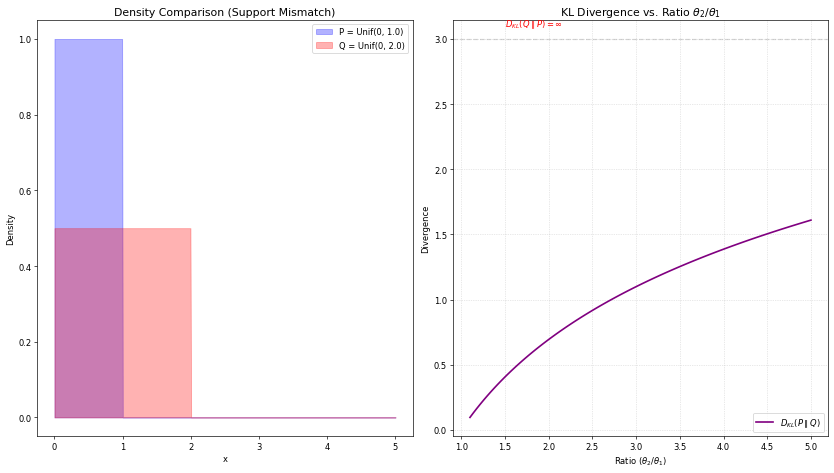

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_uniform_kl(theta1, theta2_max):
    # Range of theta2 values to test
    theta2_vals = np.linspace(theta1 + 0.1, theta2_max, 100)
    kl_pq = np.log(theta2_vals / theta1)

    # Subplot 1: PDFs using a specific theta2 for illustration
    example_theta2 = theta1 * 2
    x = np.linspace(0, theta2_max, 500)
    p_x = np.where((x >= 0) & (x <= theta1), 1/theta1, 0)
    q_x = np.where((x >= 0) & (x <= example_theta2), 1/example_theta2, 0)

    # Subplot 2: KL Divergence vs Theta Ratio

visualize_uniform_kl(theta1=1.0, theta2_max=5.0)

This visualization is particularly interesting because it demonstrates the "Infinite Penalty" rule. Since KL divergence is only finite if the support of P is a subset of the support of Q, we can visualize why the direction of the comparison matters so much.

The code below creates a consolidated figure showing the PDFs of P and Q alongside a plot of how the KL divergence behaves as the ratio of the parameters changes.

**Key Points for the Uniform Case**

- The Logarithmic Growth: Unlike the Gaussian case where divergence grew quadratically with the mean difference, here $D_{KL}(P \parallel Q)$ grows logarithmically as $\theta_2$ increases relative to $\theta_1$.
- Support Logic: In the density plot (left), you can see the "red" region from $Q$ that extends past the "blue" region of $P$. Because $Q$ has probability mass where $P$ is zero, $D_{KL}(Q \parallel P)$ is forced to infinity.
- Information Interpretation: $D_{KL}(P \parallel Q) = \ln(\theta_2/\theta_1)$ represents the amount of information lost by using a wider, less precise uniform distribution to describe a tighter one.

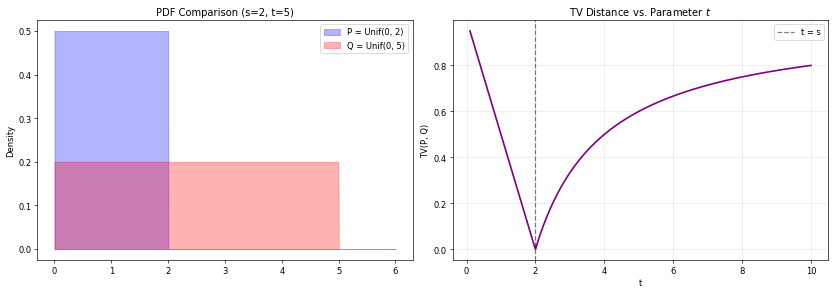

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_uniform_tv(s, t_range):
    t_vals = np.linspace(0.1, t_range, 500)
    # TV = 1 - min(s,t)/max(s,t)
    tv_vals = [1 - min(s, t)/max(s, t) for t in t_vals]

    # Left: PDFs for an example case s=2, t=5
    t_ex = 5
    x = np.linspace(0, 6, 1000)
    p_x = np.where((x >= 0) & (x <= s), 1/s, 0)
    q_x = np.where((x >= 0) & (x <= t_ex), 1/t_ex, 0)

    # Right: TV Distance vs t

visualize_uniform_tv(s=2, t_range=10)

### Kullback-Leibler divergence between two Exponential distributions

This derivation for the Exponential distribution is mathematically sound and highlights a very common pattern in the KL divergence of the Exponential family: the result often simplifies to a ratio of parameters minus 1, plus a logarithmic term.

**KL Divergence: Exponential Distributions $P = \text{Exp}(\lambda)$ and $Q = \text{Exp}(\mu)$**

Given the probability density functions for $x \geq 0$: $p(x) = \lambda e^{-\lambda x}, \quad q(x) = \mu e^{-\mu x}$ where $\lambda, \mu > 0$.

Log-likelihood ratio
- $\ln\left( \frac{p(x)}{q(x)} \right) = \ln\left( \frac{\lambda e^{-\lambda x}}{\mu e^{-\mu x}} \right)$

Using log properties
- $\ln\left( \frac{p(x)}{q(x)} \right) = \ln\left( \frac{\lambda}{\mu} \right) + \ln(e^{-\lambda x}) - \ln(e^{-\mu x})$, $\ln\left( \frac{p(x)}{q(x)} \right) = \ln\left( \frac{\lambda}{\mu} \right) - \lambda x + \mu x$, $\ln\left( \frac{p(x)}{q(x)} \right) = \ln\left( \frac{\lambda}{\mu} \right) + (\mu - \lambda)x$

Computing the Expectation $E_P$
- $D_{KL}(P \parallel Q) = E_P\left[ \ln\left( \frac{\lambda}{\mu} \right) + (\mu - \lambda)X \right]$
- Since $\ln(\lambda/\mu)$ and $(\mu - \lambda)$ are constants: $D_{KL}(P \parallel Q) = \ln\left( \frac{\lambda}{\mu} \right) + (\mu - \lambda) E_P[X]$


Final Result: Knowing that for $X \sim \text{Exp}(\lambda)$, the mean is $E[X] = \frac{1}{\lambda}$
- $D_{KL}(P \parallel Q) = \ln\left( \frac{\lambda}{\mu} \right) + (\mu - \lambda) \frac{1}{\lambda}$, $D_{KL}(P \parallel Q) = \ln\left( \frac{\lambda}{\mu} \right) + \frac{\mu}{\lambda} - 1$

Comparison of Rate Effects

When $\lambda = \mu$, the expression becomes $\ln(1) + 1 - 1 = 0$, as expected.
- If $\lambda > \mu$, the "true" distribution $P$ decays faster than $Q$.
- If $\mu > \lambda$, the "model" distribution $Q$ decays faster, meaning $Q$ underestimates the probability of seeing larger values of $X$.

For the exponential distribution, the KL divergence is particularly elegant because it highlights the relationship between the "rate" of events and information loss.

This visualization combines the PDFs (to see the physical overlap) and the divergence curve (to see the numerical penalty).

Insights from the Consolidated Figure
- The Global Minimum: Like your derivation showed, when $\mu = \lambda$, the KL divergence is exactly $0$.
- Asymmetric Penalty: Notice how the curve in the second plot isn't symmetric. The penalty for $\mu$ being much smaller than $\lambda$ (underestimating the rate) grows differently than $\mu$ being much larger than $\lambda$ (overestimating the rate).
- Shape: In the PDF plot, you can see how $\mu=0.5$ (red) creates a "heavier tail" than $P$, while $\mu=2.0$ (green) decays much faster. KL divergence quantifies exactly how much extra "surprise" is generated by these mismatches.

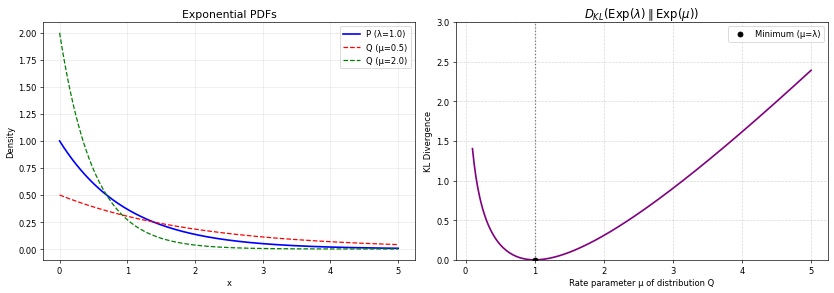

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def kl_exponential(lam, mu):
    """Computes D_KL(Exp(lam) || Exp(mu))"""
    return np.log(lam / mu) + (mu / lam) - 1

# Parameters for plotting
lam_fixed = 1.0
mu_vals = np.linspace(0.1, 5.0, 200)
kl_vals = kl_exponential(lam_fixed, mu_vals)

# Subplot 1: PDFs showing different decay rates
x = np.linspace(0, 5, 500)
# Example with mu = 0.5 (slower decay) and mu = 2.0 (faster decay)
# Subplot 2: KL Divergence vs Rate mu

### Kullback-Leibler divergence between two distributions, P and Q

This is a great breakdown of the Total Variation (TV) distance. It highlights how TV distance is essentially measuring the "lack of overlap" between two probability measures. The case where $c = \pm 1$ is the most interesting because the distributions share exactly one point in their support, and your derivation captures that transition perfectly.

**Total Variation Distance: $P = X$ and $Q = X + c$ where $X \sim \text{Ber}(p)$**

The Total Variation distance is defined as $TV(P, Q) = \frac{1}{2} \sum_{x \in \Omega} |P(x) - Q(x)|$

Given $X \in \{0, 1\}$ with $P(X=1) = p$ and $P(X=0) = 1-p$.

Case: $c \notin \{-1, 0, 1\}$
- The supports are disjoint: $\text{supp}(P) = \{0, 1\}$ and $\text{supp}(Q) = \{c, 1+c\}$.Since there is no overlap: $TV(P, Q) = 1$

Case: $c = 0$
- The distributions are identical ($P = Q$): $TV(P, Q) = 0$.

Case: $c = 1$ or $c = -1$
- For $c = 1$: $\text{supp}(P) = \{0, 1\}$ with masses $\{1-p, p\}$, $\text{supp}(Q) = \{1, 2\}$ with masses $\{1-p, p\}$. The intersection occurs only at $x=1$.
- $TV(P, Q) = \frac{1}{2} \left( |P(0) - Q(0)| + |P(1) - Q(1)| + |P(2) - Q(2)| \right)$, $TV(P, Q) = \frac{1}{2} \left( |(1-p) - 0| + |p - (1-p)| + |0 - p| \right)$
- $TV(P, Q) = \frac{1}{2} \left( (1-p) + |2p - 1| + p \right)$
- $TV(P, Q) = \frac{1}{2} (1 + |2p - 1|)$

(Note: $|2p-1|$ is equivalent to $|1-2p|$). This formula holds for $c = -1$ as well due to symmetry.

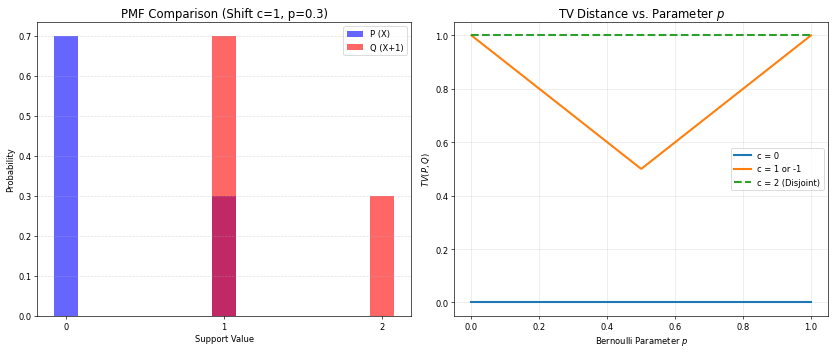

In [ ]:
def calculate_tv(p, c):
    if c == 0: return 0.0
    elif abs(c) == 1: return 0.5 * (1 + abs(2*p - 1))
    else: return 1.0

p_vals = np.linspace(0, 1, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=60)

# Panel 1: PMF visualization for c=1, p=0.3
# Panel 2: TV distance vs p for various c

### Kullback-Leibler divergence between two distributions, P and Q


**Total Variation: $\text{sign}(X)$ vs. $Y - 1$**

Distribution of $\text{sign}(X)$
- Let $X \sim {N}(\mu, \sigma^2)$. The probability of $X$ being positive or negative is determined by the standard normal CDF, $\Phi$
- $P(\text{sign}(X) = -1) = P(X < 0) = P\left(\frac{X-\mu}{\sigma} < \frac{-\mu}{\sigma}\right) = \Phi\left(-\frac{\mu}{\sigma}\right)$
$P(\text{sign}(X) = 1) = P(X > 0) = 1 - \Phi\left(-\frac{\mu}{\sigma}\right) = \Phi\left(\frac{\mu}{\sigma}\right)$
$P(\text{sign}(X) = 0) = 0$ (for continuous distributions)


Distribution of $Q = Y - 1$
- Since $Y \sim \text{Ber}(p)$, where $Y \in \{0, 1\}$:$P(Q = 0) = P(Y = 1) = p$$P(Q = -1) = P(Y = 0) = 1 - p$$P(Q = 1) = 0$


Computing $TV(\text{sign}(X), Q)$
- The total variation is $\frac{1}{2} \sum_{k \in \{-1, 0, 1\}} |P(\text{sign}(X)=k) - P(Q=k)|$. Substituting the probabilities
- $2 \cdot TV = \underbrace{\left| \Phi\left(-\frac{\mu}{\sigma}\right) - (1-p) \right|}_{\text{at } k=-1} + \underbrace{|0 - p|}_{\text{at } k=0} + \underbrace{\left| \Phi\left(\frac{\mu}{\sigma}\right) - 0 \right|}_{\text{at } k=1}$
- Since $\Phi\left(\frac{\mu}{\sigma}\right)$ and $p$ are non-negative:$$TV(\text{sign}(X), Y-1) = \frac{1}{2} \left[ \left| \Phi\left(-\frac{\mu}{\sigma}\right) - 1 + p \right| + p + \Phi\left(\frac{\mu}{\sigma}\right) \right]$$Using the identity $\Phi(z) + \Phi(-z) = 1$, we can rewrite $\Phi\left(-\frac{\mu}{\sigma}\right) - 1$ as $-\Phi\left(\frac{\mu}{\sigma}\right)$
- $TV(\text{sign}(X), Y-1) = \frac{1}{2} \left[ \left| p - \Phi\left(\frac{\mu}{\sigma}\right) \right| + p + \Phi\left(\frac{\mu}{\sigma}\right) \right]$




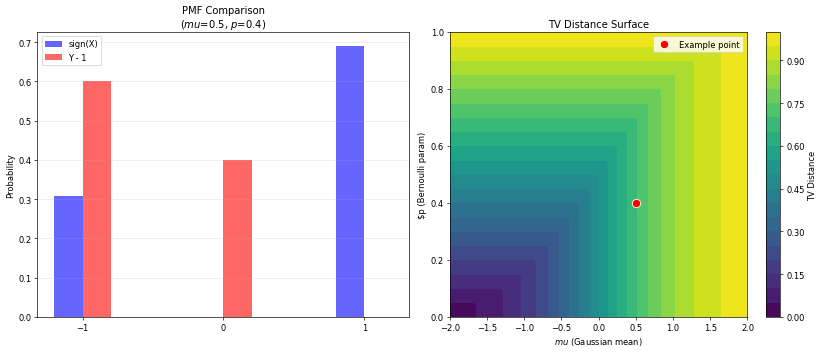

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def calculate_tv_transformed(mu, sigma, p):
    phi_val = norm.cdf(mu / sigma)
    # Using the derived formula: 0.5 * (|p - phi| + p + phi)
    return 0.5 * (np.abs(p - phi_val) + p + phi_val)

# Parameters
mu_val = 0.5
sigma_val = 1.0
p_val = 0.4

# Left: PMF comparison
support = [-1, 0, 1]
# sign(X) probabilities
phi_neg = norm.cdf(-mu_val / sigma_val)
phi_pos = norm.cdf(mu_val / sigma_val)
p_probs = [phi_neg, 0, phi_pos]

# Y-1 probabilities
q_probs = [1 - p_val, p_val, 0]

# Right: TV Distance Surface
mu_range = np.linspace(-2, 2, 100)
p_range = np.linspace(0, 1, 100)
MU, P = np.meshgrid(mu_range, p_range)
TV = calculate_tv_transformed(MU, sigma_val, P)

cp = ax2.contourf(MU, P, TV, levels=20, cmap='viridis')
# Add a marker for the current example

### Kullback-Leibler divergence between two distributions, P and Q


This derivation effectively connects the Total Variation (TV) distance with the Law of Large Numbers (LLN). It demonstrates that as your sample size increases, the distance between the distribution defined by the empirical mean and the true distribution vanishes.

**TV Distance between two Bernoulli Distributions**

Given $P \sim \text{Ber}(p)$ and $Q \sim \text{Ber}(q)$
- $TV(\text{Ber}(p), \text{Ber}(q)) = \frac{1}{2} \sum_{x \in \{0,1\}} |P(x) - Q(x)|$
- $TV(\text{Ber}(p), \text{Ber}(q)) = \frac{1}{2} \left( |p - q| + |(1 - p) - (1 - q)| \right)$
- $TV(\text{Ber}(p), \text{Ber}(q)) = \frac{1}{2} \left( |p - q| + |q - p| \right) = |p - q|$

Convergence of the Empirical Average
- Let $X_1, \dots, X_n \overset{iid}{\sim} \text{Ber}(p)$. The empirical average is defined as $\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$
- By the Weak Law of Large Numbers (WLLN), the sample mean converges in probability to the true mean $\bar{X}_n \xrightarrow{P} p \quad \text{as } n \to \infty$.
- This is formally expressed as $\forall \epsilon > 0, \lim_{n \to \infty} P(|\bar{X}_n - p| > \epsilon) = 0$

Convergence of TV Distance
- We now consider the TV distance between the estimated distribution $\text{Ber}(\bar{X}_n)$ and the true distribution $\text{Ber}(p)$
- $TV(\text{Ber}(\bar{X}_n), \text{Ber}(p)) = |\bar{X}_n - p|$
- $Since $\bar{X}_n$ converges in probability to $p$, and the absolute difference is a continuous function: $TV(\text{Ber}(\bar{X}_n), \text{Ber}(p)) \xrightarrow{P} 0 \quad \text{as } n \to \infty$

Conclusion: The total variation distance between the empirical Bernoulli distribution and the true Bernoulli distribution converges in probability to $0$ as $n \to \infty$.


Visualization of Convergence

As $n$ increases, the "fluctuations" of $\bar{X}_n$ around $p$ become smaller. Because the TV distance is exactly the absolute error $|\bar{X}_n - p|$, the TV distance effectively "shrinks" at a rate of $1/\sqrt{n}$ (following the Central Limit Theorem).


To visualize the convergence of the Total Variation distance, we can simulate the "path" of a single experiment as $n$ increases and compare it to the distribution of the TV distance across many trials.

This code generates a two-panel figure
- Left Panel: A single realization showing the sample mean $\bar{X}_n$ approaching $p$ (and thus the TV distance approaching 0).
- Right Panel: Histograms of the TV distance for different values of $n$. This illustrates the "convergence in probability"—as $n$ grows, the probability mass concentrates increasingly at 0.

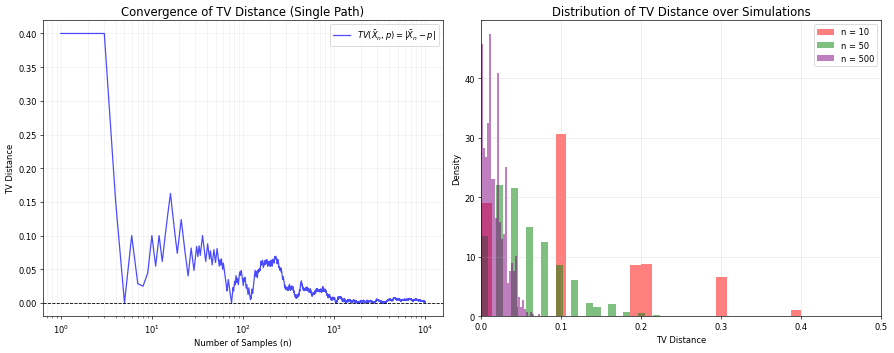

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_bernoulli_convergence(p_true, n_max, num_simulations):
    # 1. Single Path Simulation
    trials = np.random.binomial(1, p_true, n_max)
    n_values = np.arange(1, n_max + 1)
    empirical_means = np.cumsum(trials) / n_values
    tv_distances = np.abs(empirical_means - p_true)

    # 2. Distribution over many simulations for different n
    n_snapshots = [10, 50, 500]
    dist_data = {n: [] for n in n_snapshots}

    for _ in range(num_simulations):
        for n in n_snapshots:
            sample = np.random.binomial(n, p_true) / n
            dist_data[n].append(np.abs(sample - p_true))

    # Plotting
    # Left: Convergence of a single path
    # Right: Histograms of TV distance (Convergence in Probability)

# Parameters: True p = 0.6, up to 10,000 samples, 1000 simulations
visualize_bernoulli_convergence(p_true=0.6, n_max=10000, num_simulations=1000)